## Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Esto es para que las gráficas 2D se vean bien en el notebook
%matplotlib inline

> **Nota aclaratoria:** La resolución y explicación de los ejercicios de este laboratorio han sido desarrolladas con la asistencia de Inteligencia Artificial, específicamente utilizando Google AI Studio y el modelo Gemini.

# Lab 5: Regresión multivariada

> **1. Para simular un conjunto de características $x_1 , x_2 ,..., x_n$ trabajaremos en la primera parte con dos características de datos aleatorios que presentan un plano y mostraremos que los párametros optimizados se corresponden con el valor esperado.**


> * **Definir la ecuación $y = 2.1 * x_1 - 3.1 * x_2$, y generar números aleatorios que pertenecen al plano.**


Generaremos un conjunto de 100 muestras aleatorias donde las características $x_1$ y $x_2$ estarán acotadas entre -1 y 1. La variable objetivo $y$ se definirá mediante la ecuación:

$$y = 2.1x_1 - 3.1x_2$$

El objetivo del algoritmo será descubrir los parámetros: $\theta_0 = 0$, $\theta_1 = 2.1$ y $\theta_2 = -3.1$.

Empaquetaremos estos datos en una matriz de diseño $X$ de dimensiones $(n+1, m)$, agregando una fila de unos (`1`) correspondiente al término independiente $\theta_0$.

In [2]:
np.random.seed(42)
N = 100

# Generamos características aleatorias entre -1 y 1
x_1 = 2 * np.random.random(N) - 1
x_2 = 2 * np.random.random(N) - 1

# Generamos la variable objetivo y
y_label = 2.1 * x_1 - 3.1 * x_2

# Construimos el DataFrame
df = pd.DataFrame({"x1": x_1, "x2": x_2, "y": y_label})

# Añadimos la columna de unos para el término independiente
df["ones"] = 1

# Creamos las matrices X e Y según las dimensiones teóricas (n+1, m)
X = df[["ones", "x1", "x2"]].values.T
Y = df.y.values.reshape(1, N)

Nfeatures = np.shape(X)[0]
m = np.shape(X)[1]

print(f"Número de características (incluyendo intercepto): {Nfeatures}")
print(f"Número de muestras (m): {m}")
print(f"Forma de la matriz X: {X.shape}")
print(f"Forma de la matriz Y: {Y.shape}")

Número de características (incluyendo intercepto): 3
Número de muestras (m): 100
Forma de la matriz X: (3, 100)
Forma de la matriz Y: (1, 100)


> * **Realizar un diagrama 3D de los puntos generados aleatoriamente.**

Crearemos un gráfico tridimensional interactivo utilizando `plotly` para comprobar visualmente que los datos generados se ubican exactamente sobre la superficie del plano definido.

In [3]:
# Malla para dibujar la superficie del plano
x1_malla = np.linspace(-1, 1, 100)
x2_malla = np.linspace(-1, 1, 100)
X_1_mesh, X_2_mesh = np.meshgrid(x1_malla, x2_malla)

# Superficie teórica
Z_superficie = 2.1 * X_1_mesh - 3.1 * X_2_mesh

fig = go.Figure()

# Superficie del plano
fig.add_trace(go.Surface(x=X_1_mesh, y=X_2_mesh, z=Z_superficie,
                         colorscale='Viridis', opacity=0.7, name='Plano Real'))

# Puntos generados
fig.add_trace(go.Scatter3d(x=x_1, y=x_2, z=y_label,
                           mode='markers',
                           marker=dict(size=4, color='red', line=dict(width=1, color='darkred')),
                           name='Datos Generados'))

fig.update_layout(title='Diagrama 3D de los datos y el plano objetivo',
                  scene=dict(xaxis_title='Variable x1',
                             yaxis_title='Variable x2',
                             zaxis_title='Objetivo y'),
                  width=800, height=600) # Visualización
fig.show()

**Nota sobre las implementaciones de referencia:**
Al revisar los fragmentos de código de ayuda proporcionados al final del laboratorio, se observan dos detalles importantes:
1. Utilizan una ecuación objetivo diferente ($y = 0.2x_1 - 0.5x_2$) a la solicitada explícitamente al inicio de la guía.
2. La función de actualización del gradiente en el código de ayuda omite la división sobre $m$ (el número de muestras), lo cual altera la escala de la tasa de aprendizaje ($\alpha$).

Para mantener el rigor matemático y cumplir con las instrucciones principales, el siguiente código mantendrá los parámetros objetivo solicitados ($2.1$ y $-3.1$) e implementará la forma vectorizada estándar del gradiente que incluye la división por $m$.

> **2. Inicializar conjunto de parámetros $\Theta$ de manera aleatoria.**

In [4]:
# Inicializar conjunto de parámetros Theta de manera aleatoria
np.random.seed(42) # Para reproducibilidad
theta_inicial = np.random.random((Nfeatures, 1))

print("Theta inicial (aleatorio):")
print(theta_inicial)

Theta inicial (aleatorio):
[[0.37454012]
 [0.95071431]
 [0.73199394]]


**Vectorización de las Ecuaciones**

Utilizaremos el producto punto de matrices (operador `@` o `np.dot` en Python) para eliminar la necesidad de bucles `for` al calcular las predicciones y los gradientes sobre todo el conjunto de datos a la vez.

*   **Matriz $X$**: Tiene dimensiones `(3, m)`.
*   **Vector $\Theta$**: Tiene dimensiones `(3, 1)`.
*   **Vector $Y$**: Tiene dimensiones `(1, m)`.

> **3. Construir la matrix X con dimensiones $(n + 1, m)$, m es el numero de datos de entrenamiento y (n) el número de caracteristicas.**

In [5]:
def model(theta, X):
    """
    Calcula la hipótesis h de forma vectorizada.
    theta.T es de dimensiones (1, 3) y X es (3, m).
    El resultado es una matriz de predicciones de (1, m).
    """
    return theta.T @ X

> **4. Calcular la función de coste(revise cuidosamente las dimensiones de cada matriz):**
> * $h = \Theta^T X$
> * $\Lambda = (h - Y)$
> * $\Lambda* = (h - Y)^2$
> * $\Lambda =[\Lambda_1, \Lambda_2, \dots, \Lambda_m]$
> * $J = \frac{1}{2m} \sum_{i}^m \Lambda_i$

In [6]:
def costo(h, Y):
    """
    Calcula la función de coste J (Error Cuadrático Medio).
    Se divide por 2m según la ecuación matemática estándar.
    """
    m = Y.shape[1]
    errores = h - Y
    J = np.sum(errores ** 2) / (2 * m)
    return J

> **5. Aplicar el gradiente descendente:**
> * **Encontrar el gradiente. $\nabla J = \Lambda X^T$**
> * **Actualizar los nuevos parametros: $\Theta_{n+1} = \Theta_n - \alpha \nabla J$**

In [7]:
def update_params(theta, h, Y, X, learning_rate):
    """
    Calcula el gradiente descendente y actualiza el vector theta.
    """
    m = Y.shape[1]
    errores = h - Y

    # Gradiente vectorizado: (1/m) * X * (h-Y)^T
    # Dimensiones: (3, m) @ (m, 1) -> (3, 1)
    grad = (1 / m) * (X @ errores.T)

    theta_actualizado = theta - learning_rate * grad
    return theta_actualizado

> **6. Iterar para encontrar los valores $\Theta$ que se ajustan el plano.**

**Entrenamiento: Bucle de Gradiente Descendente**

Procederemos a iterar sobre las funciones definidas anteriormente. En cada iteración:
1. Calculamos la predicción actual.
2. Evaluamos el coste (error) y lo almacenamos para su posterior visualización.
3. Actualizamos los parámetros $\Theta$ utilizando el gradiente descendente.

Configuraremos una tasa de aprendizaje (`learning_rate`) y un número de iteraciones (`Niter`) adecuados para asegurar la convergencia del algoritmo. Al finalizar, compararemos los parámetros obtenidos con los de la ecuación original ($0$, $2.1$ y $-3.1$).

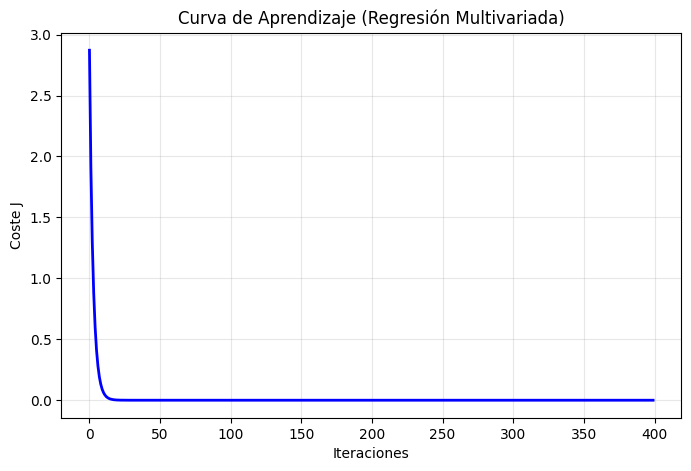

Parámetros finales encontrados (Theta):
theta_0 (Intercepto) : 0.0000
theta_1 (Peso x1)    : 2.1000
theta_2 (Peso x2)    : -3.1000

Valores teóricos esperados:
theta_0 =  0.0
theta_1 =  2.1
theta_2 = -3.1


In [8]:
# Restauramos el valor inicial aleatorio para empezar el entrenamiento desde cero
theta = theta_inicial.copy()

# Hiperparámetros del entrenamiento
learning_rate = 0.5
Niter = 400
J_history = np.zeros(Niter)

# Bucle de entrenamiento
for i in range(Niter):
    h = model(theta, X)
    J_history[i] = costo(h, Y)
    theta = update_params(theta, h, Y, X, learning_rate)

# Visualización de la curva de aprendizaje
plt.figure(figsize=(8, 5))
plt.plot(J_history, color='blue', linewidth=2)
plt.title('Curva de Aprendizaje (Regresión Multivariada)')
plt.xlabel('Iteraciones')
plt.ylabel('Coste J')
plt.grid(True, alpha=0.3)
plt.show()

# Resultados finales
print("Parámetros finales encontrados (Theta):")
print(f"theta_0 (Intercepto) : {theta[0, 0]:.4f}")
print(f"theta_1 (Peso x1)    : {theta[1, 0]:.4f}")
print(f"theta_2 (Peso x2)    : {theta[2, 0]:.4f}")

print("\nValores teóricos esperados:")
print("theta_0 =  0.0")
print("theta_1 =  2.1")
print("theta_2 = -3.1")

> **7. Reescribir su código como una clase (ver ayuda)**

**Empaquetado del Modelo (POO)**

A continuación, reescribiremos nuestro código procedimental utilizando el paradigma de Programación Orientada a Objetos (POO). Completaremos el esqueleto de la clase `MultilinearRegresion` proporcionado en el laboratorio.

Al encapsular el modelo en una clase, los datos (`X`, `Y`) y los parámetros (`theta`, `h`, `J`) se convierten en **atributos** de la instancia (`self.X`, `self.theta`, etc.). Las funciones se convierten en **métodos** de la clase, los cuales modifican el estado interno sin necesidad de pasar variables constantemente de una función a otra.

*Nota: Hemos añadido el parámetro `iteraciones` a la función `fit` para hacerlo más flexible y hemos incluido el almacenamiento del historial de la función de coste para poder graficarlo.*

In [9]:
class MultilinearRegresion():
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
        self.Nfeatures = np.shape(X)[0]
        self.m = np.shape(X)[1]

        # Inicializamos theta aleatoriamente
        np.random.seed(42)
        self.theta = np.random.random((self.Nfeatures, 1))

        # Atributos para almacenar predicciones, coste e historial
        self.h = None
        self.J = None
        self.J_history =[]

    def model(self):
        """Calcula la hipótesis h(X)"""
        self.h = self.theta.T @ self.X
        return self.h

    def costo(self):
        """Calcula la función de coste J"""
        errores = self.h - self.Y
        self.J = np.sum(errores**2) / (2 * self.m)
        return self.J

    def update_params(self, learning_rate):
        """
        Calcula el gradiente descendente y actualiza los parámetros.
        """
        errores = self.h - self.Y
        # Gradiente vectorizado
        grad = (1 / self.m) * (self.X @ errores.T)
        self.theta = self.theta - learning_rate * grad

    def fit(self, learning_rate, iteraciones=100):
        """Ciclo de entrenamiento del modelo"""
        self.J_history = np.zeros(iteraciones)

        for i in range(iteraciones):
            self.model()
            self.J_history[i] = self.costo()
            self.update_params(learning_rate)

**Validación del Modelo Orientado a Objetos**

Instanciaremos nuestra nueva clase con las matrices $X$ e $Y$ generadas en la Fase 1, la entrenaremos y graficaremos los resultados para verificar que el comportamiento es idéntico a nuestra implementación procedimental.

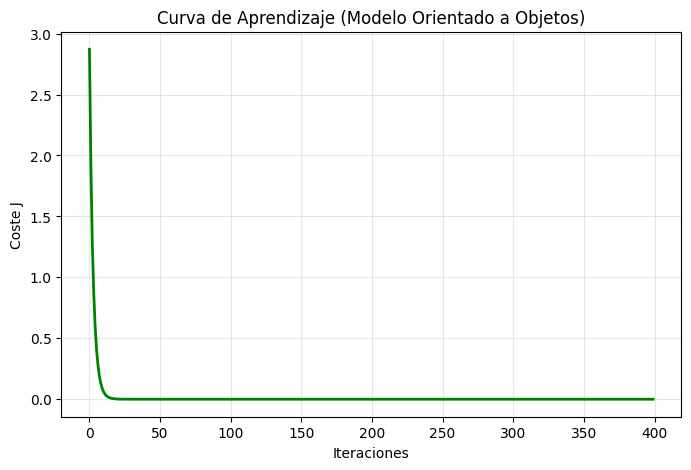

Parámetros descubiertos por la Clase (Theta):
theta_0 (Intercepto) : 0.0000
theta_1 (Peso x1)    : 2.1000
theta_2 (Peso x2)    : -3.1000


In [10]:
# Instanciamos la clase con nuestros datos
modelo_multivariado = MultilinearRegresion(X, Y)

# Entrenamos el modelo (usamos el learning rate y las iteraciones óptimas encontradas en la fase 3)
modelo_multivariado.fit(learning_rate=0.5, iteraciones=400)

# Graficamos el historial de coste guardado en el atributo de la clase
plt.figure(figsize=(8, 5))
plt.plot(modelo_multivariado.J_history, color='green', linewidth=2)
plt.title('Curva de Aprendizaje (Modelo Orientado a Objetos)')
plt.xlabel('Iteraciones')
plt.ylabel('Coste J')
plt.grid(True, alpha=0.3)
plt.show()

# Imprimimos los parámetros finales alojados en el atributo theta
print("Parámetros descubiertos por la Clase (Theta):")
print(f"theta_0 (Intercepto) : {modelo_multivariado.theta[0, 0]:.4f}")
print(f"theta_1 (Peso x1)    : {modelo_multivariado.theta[1, 0]:.4f}")
print(f"theta_2 (Peso x2)    : {modelo_multivariado.theta[2, 0]:.4f}")